# Qwen3.5-0.8B serving smoke experiment

This notebook is the analysis and launch surface for `qwen35-0.8b-smoke`. It loads the real YAML profile, expands the same matrix as the CLI, reads the harness's canonical `manifest.json` and `summary.json` artifacts, and keeps quality evidence separate from performance.

**Safe default:** Run All is offline and read-only. It does not connect over SSH, provision a Pod, invoke the runner, or make a paid call. The launch cell runs only after `RUN_EXPERIMENT = True` is set deliberately.

In [1]:
from pathlib import Path
import os
import shlex
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Markdown, SVG, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'experiment_profiles' / 'qwen35-0.8b-smoke.yaml').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from within the llm-serving checkout.')

PROJECT_ROOT = find_project_root(Path.cwd())
PROFILE_PATH = PROJECT_ROOT / 'experiment_profiles' / 'qwen35-0.8b-smoke.yaml'
OUTPUT_ROOT = Path(os.environ.get('LLM_SERVING_OUTPUT_ROOT', PROJECT_ROOT / 'output')).expanduser().resolve()

from llm_serving.analysis import (
    comparable_quality_groups, discover_runs, history_rows, performance_rows,
    plot_baseline_deltas, plot_performance, plot_quality, quality_rows, write_run_notes,
)
from llm_serving.matrix import expand_matrix
from llm_serving.profiling import kernel_rows, trace_rows
from llm_serving.schemas import ExperimentProfile

print(f'Project: {PROJECT_ROOT}')
print(f'Artifact root: {OUTPUT_ROOT}')

Project: /home/kevin/Workspace/toyai/llm-serving
Artifact root: /home/kevin/Workspace/toyai/llm-serving/output


## Question and hypothesis

The smoke profile asks whether CUDA graph execution improves Qwen3.5-0.8B serving performance for short-interactive, long-prefill, near-limit-prefill, and decode-heavy traffic while chunked prefill remains enabled for the model's aligned Mamba cache mode.

The working hypothesis is that CUDA graphs increase output throughput and reduce inter-token latency most clearly on decode-heavy traffic. GSM8K and SuperGLUE are separate 10-example smoke-quality checks; their results are not full benchmark scores and must not be used to explain a performance delta. The 256K serving cap is the model's full advertised context window.

In [2]:
profile_raw = yaml.safe_load(PROFILE_PATH.read_text(encoding='utf-8'))
profile = ExperimentProfile.model_validate(profile_raw)
display(Markdown(f'**Loaded profile:** `{PROFILE_PATH}`  \n**Model:** `{profile.model.id}` at revision `{profile.model.revision}`'))
pd.json_normalize(profile.model_dump(), sep='.').T.rename(columns={0: 'resolved value'})

**Loaded profile:** `/home/kevin/Workspace/toyai/llm-serving/experiment_profiles/qwen35-0.8b-smoke.yaml`  
**Model:** `Qwen/Qwen3.5-0.8B` at revision `main`

,resolved value
schema_version,1
name,qwen35-0.8b-smoke
model.id,Qwen/Qwen3.5-0.8B
model.revision,main
model.variant,BF16
model.dtype,auto
model.quantization,None
model.model_card.url,https://huggingface.co/Qwen/Qwen3.5-0.8B
model.model_card.config_url,https://huggingface.co/Qwen/Qwen3.5-0.8B/blob/...
model.model_card.max_position_embeddings,262144


## Resolved experiment matrix

This uses the harness's matrix expansion rather than reimplementing it in the notebook. The first row is the within-run baseline used by the saved reports.

In [3]:
matrix = expand_matrix(profile)
matrix_df = pd.DataFrame([
    {
        'case_id': case.case_id, 'baseline': case.is_baseline,
        'cuda_graphs': case.cuda_graphs, 'chunked_prefill': case.chunked_prefill,
        'repetition': case.repetition, 'vllm_args': shlex.join(case.vllm_args),
    }
    for case in matrix
])
matrix_df

,case_id,baseline,cuda_graphs,chunked_prefill,repetition,vllm_args
0,case-00-cg1-cp1-rep0,True,True,True,0,--model Qwen/Qwen3.5-0.8B --revision main --te...
1,case-01-cg0-cp1-rep0,False,False,True,0,--model Qwen/Qwen3.5-0.8B --revision main --te...


## Explicit launch controls

This experiment uses the `runpod-qwen08` host alias. Supply `LLM_SERVING_HOST_INVENTORY` with the absolute path to the generated RunPod inventory (for example, `.flash/hosts/<pod-id>.yaml`). That generated file can contain temporary connection details, so it is intentionally external to Git. The existing harness command runs only when the switch in the next cell is changed to `True`.

Set the hypothesis before launch so the new run receives an `experiment-notes.json` sidecar. The notebook creates that sidecar only for the newly created run and refuses to replace an existing notes file.

In [4]:
HOST = os.environ.get('LLM_SERVING_HOST', 'runpod-qwen08')
host_inventory_env = os.environ.get('LLM_SERVING_HOST_INVENTORY')
HOST_INVENTORY = Path(host_inventory_env).expanduser() if host_inventory_env else None
HYPOTHESIS = 'CUDA graphs improve decode-heavy throughput and ITL on this host.'
INITIAL_OBSERVATIONS = ''

inventory_argument = str(HOST_INVENTORY) if HOST_INVENTORY else '<set LLM_SERVING_HOST_INVENTORY>'
plan_command = [sys.executable, '-m', 'llm_serving.cli', 'plan', str(PROFILE_PATH), '--host', HOST, '--inventory', inventory_argument]
run_command = [sys.executable, '-m', 'llm_serving.cli', 'run', str(PROFILE_PATH), '--host', HOST, '--inventory', inventory_argument, '--output-dir', str(OUTPUT_ROOT)]
display(Markdown('**Offline plan preview**\n```shell\n' + shlex.join(plan_command) + '\n```'))
display(Markdown('**Existing-harness run preview**\n```shell\n' + shlex.join(run_command) + '\n```'))

**Offline plan preview**
```shell
/home/kevin/Workspace/toyai/llm-serving/.venv/bin/python3 -m llm_serving.cli plan /home/kevin/Workspace/toyai/llm-serving/experiment_profiles/qwen35-0.8b-smoke.yaml --host runpod-qwen08 --inventory '<set LLM_SERVING_HOST_INVENTORY>'
```

**Existing-harness run preview**
```shell
/home/kevin/Workspace/toyai/llm-serving/.venv/bin/python3 -m llm_serving.cli run /home/kevin/Workspace/toyai/llm-serving/experiment_profiles/qwen35-0.8b-smoke.yaml --host runpod-qwen08 --inventory '<set LLM_SERVING_HOST_INVENTORY>' --output-dir /home/kevin/Workspace/toyai/llm-serving/output
```

In [5]:
RUN_EXPERIMENT = os.environ.get('LLM_SERVING_RUN_EXPERIMENT', '').lower() in {'1', 'true', 'yes'}  # Deliberate opt-in: may use SSH/GPU resources and incur cost.

if not RUN_EXPERIMENT:
    print('Analysis-only mode: no validation, SSH, provisioning, or experiment run was started.')
else:
    if not HOST:
        raise ValueError('Set LLM_SERVING_HOST or edit HOST before launching.')
    if HOST_INVENTORY is None:
        raise ValueError('Set LLM_SERVING_HOST_INVENTORY to the generated RunPod host inventory before launching.')
    if not HOST_INVENTORY.is_file():
        raise FileNotFoundError(f'Host inventory not found: {HOST_INVENTORY}')
    run_parent = OUTPUT_ROOT / profile.name
    before = {path for path in run_parent.iterdir() if path.is_dir() and (path / 'summary.json').is_file()} if run_parent.is_dir() else set()
    completed = subprocess.run(run_command, cwd=PROJECT_ROOT, check=False)
    after = {path for path in run_parent.iterdir() if path.is_dir() and (path / 'summary.json').is_file()}
    created = sorted(after - before)
    if len(created) == 1:
        notes_path = write_run_notes(created[0], hypothesis=HYPOTHESIS, observations=INITIAL_OBSERVATIONS)
        print(f'Run notes created: {notes_path}')
    else:
        raise RuntimeError(f'Expected one new run directory, found {created}')
    print(f'Harness exit code: {completed.returncode}. Failed runs remain available for analysis.')

Analysis-only mode: no validation, SSH, provisioning, or experiment run was started.


## Saved run history

The reader includes failed and partial runs. Missing files and metrics remain visible warnings or blank values; they are never replaced with zero. If no compatible measured run exists, tables and charts state that results are unavailable.

In [6]:
all_measured_runs = discover_runs(OUTPUT_ROOT, profile_name=profile.name, source='measured')

def recorded_context_limit(run):
    return ((run.get('profile') or {}).get('server') or {}).get('max_model_len')


measured_runs = [run for run in all_measured_runs if recorded_context_limit(run) == profile.server.max_model_len]
incompatible_runs = [run for run in all_measured_runs if recorded_context_limit(run) != profile.server.max_model_len]
history = measured_runs
if incompatible_runs:
    excluded = ', '.join(run['run_id'] for run in incompatible_runs)
    display(Markdown(f'> **Excluded measured run(s):** `{excluded}` used a different `server.max_model_len`; set `LLM_SERVING_RUN_IDS` only after running this 256K profile.'))

if measured_runs:
    display(Markdown(f'**Measured artifact history:** {len(measured_runs)} run(s) found.'))
else:
    display(Markdown('> **No compatible measured runs found.** Run this 256K profile to populate the analysis.'))
pd.DataFrame(history_rows(history))

> **Excluded measured run(s):** `20260907_050924, 20260907_045529, 20260907_043253, 20260907_042613, 20260907_042337, 20260907_042256, 20260907_042221, 20260907_042136, 20260907_041957` used a different `server.max_model_len`; set `LLM_SERVING_RUN_IDS` only after running this 256K profile.

> **No compatible measured runs found.** Run this 256K profile to populate the analysis.

""


## Performance results

These panels show throughput, TTFT p50/p95, ITL p50/p95, and end-to-end latency only where the artifacts record them. Blue bars are baseline cases and orange bars are alternatives. Variability is not drawn because the current profile has one repetition per case; increase repetitions before interpreting run-to-run spread.

In [7]:
measured_performance = performance_rows(measured_runs)
requested_ids = {value.strip() for value in os.environ.get('LLM_SERVING_RUN_IDS', '').split(',') if value.strip()}
if measured_performance:
    if requested_ids:
        analysis_runs = [run for run in measured_runs if run['run_id'] in requested_ids]
        if not performance_rows(analysis_runs):
            raise ValueError(f'LLM_SERVING_RUN_IDS selected no runs with performance rows: {sorted(requested_ids)}')
    else:
        analysis_runs = [next((run for run in measured_runs if run['complete'] and performance_rows([run])), next(run for run in measured_runs if performance_rows([run])))]
    display(Markdown('**Data source: measured harness artifacts.** Charts show the latest complete run by default; set `LLM_SERVING_RUN_IDS` to a comma-separated list for an explicit comparison.'))
else:
    analysis_runs = []
    display(Markdown('> **No compatible measured performance results.** Charts below show unavailable panels until this 256K profile completes.'))
perf = performance_rows(analysis_runs)
perf_df = pd.DataFrame(perf)
columns = ['run_id', 'source', 'case_id', 'case_status', 'config', 'workload', 'output_throughput_tok_per_s', 'ttft_p50_ms', 'ttft_p95_ms', 'itl_p50_ms', 'itl_p95_ms', 'e2e_p50_ms']
perf_df.reindex(columns=columns)

> **No compatible measured performance results.** Charts below show unavailable panels until this 256K profile completes.

,run_id,source,case_id,case_status,config,workload,output_throughput_tok_per_s,ttft_p50_ms,ttft_p95_ms,itl_p50_ms,itl_p95_ms,e2e_p50_ms


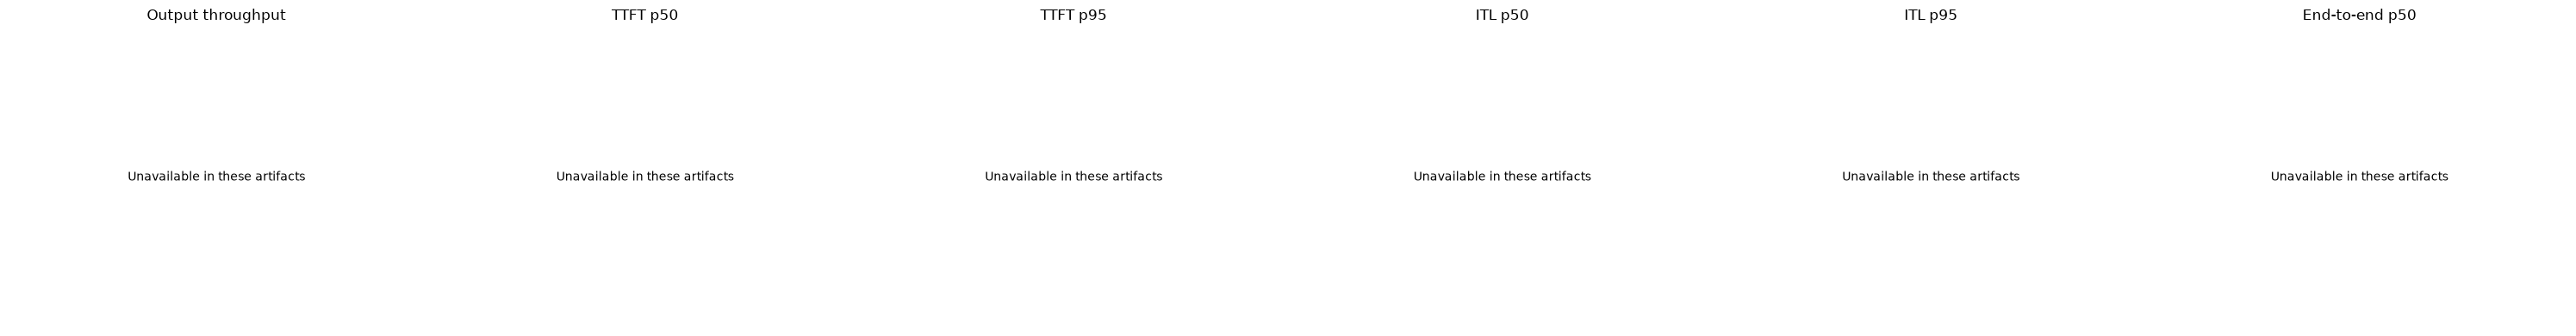

In [8]:
plot_performance(perf);


## Within-run baseline deltas

Deltas come directly from each canonical summary. Throughput gains are favorable; latency reductions are favorable. Cross-run deltas are not synthesized when hardware, runtime, or workload identity may differ.

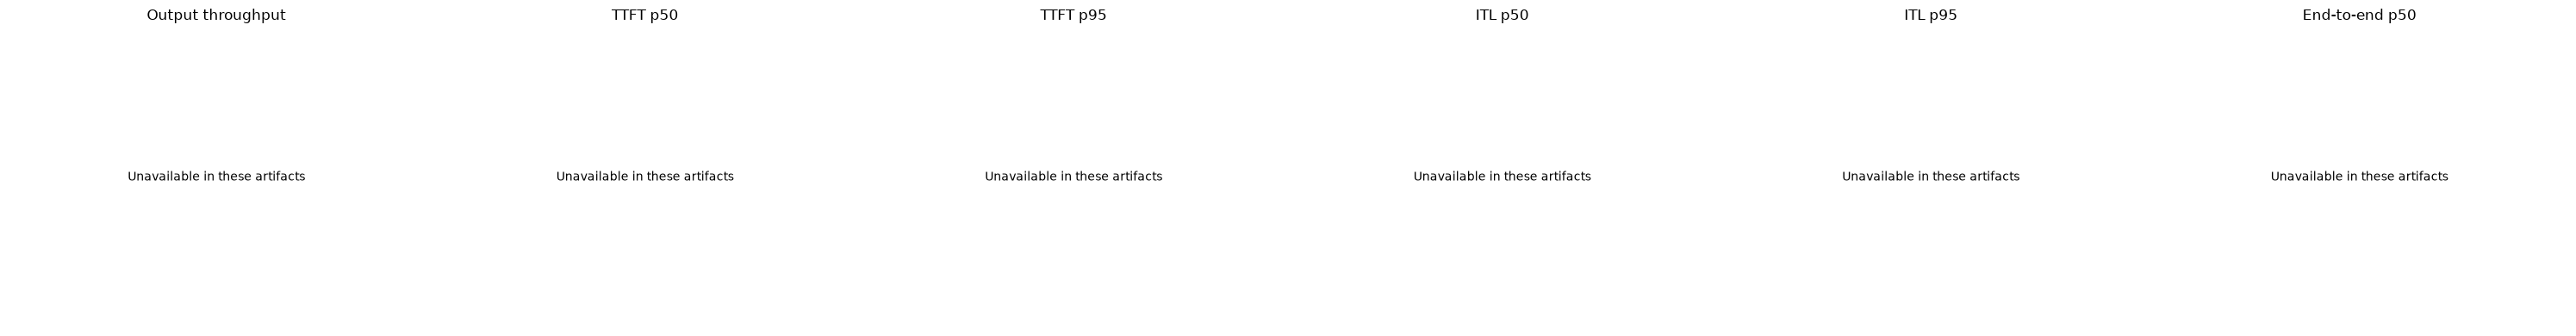

In [9]:
plot_baseline_deltas(perf);


## Bounded PyTorch profile comparison

The companion `qwen35-0.8b-profile` manifest captures the decode-heavy workload once per serving configuration. Profiled throughput and latency include tracing overhead, so the table is diagnostic only. The SVG below aggregates CUDA kernel event durations from each worker trace; overlapping streams mean these sums are not wall time, utilization, or critical-path attribution. Load the saved `.pt.trace.json.gz` files in Perfetto for the full interactive timeline.

In [10]:
profile_runs = discover_runs(OUTPUT_ROOT, profile_name='qwen35-0.8b-profile', source='measured')
profile_runs_with_traces = [candidate for candidate in profile_runs if trace_rows(candidate['run_dir'])]
profile_run = profile_runs_with_traces[0] if profile_runs_with_traces else None
profile_diagnostic = performance_rows([profile_run], include_profiled=True) if profile_run else []
profile_diagnostic = [row for row in profile_diagnostic if row.get('profiled')]
profile_columns = ['run_id', 'case_id', 'config', 'workload', 'output_throughput_tok_per_s', 'ttft_p95_ms', 'itl_p95_ms']
if profile_run:
    display(Markdown(f"**Profile run:** `{profile_run['run_id']}` — `{profile_run['status']}`  \
**Trace directory:** `{profile_run['run_dir'] / 'cases'}`"))
    display(pd.DataFrame(profile_diagnostic).reindex(columns=profile_columns))
else:
    display(Markdown('> **No saved torch profile found.** Run `qwen35-0.8b-profile` to populate the diagnostic comparison.'))

**Profile run:** `20260929_075740` — `SUCCESS`  **Trace directory:** `/home/kevin/Workspace/toyai/llm-serving/output/qwen35-0.8b-profile/20260929_075740/cases`

,run_id,case_id,config,workload,output_throughput_tok_per_s,ttft_p95_ms,itl_p95_ms
0,20260929_075740,case-00-cg1-cp1-rep0,CG on / CP on,Decode heavy,1856.506587,105.807612,3.493850
1,20260929_075740,case-01-cg0-cp1-rep0,CG off / CP on,Decode heavy,443.388307,5427.482326,38.381692


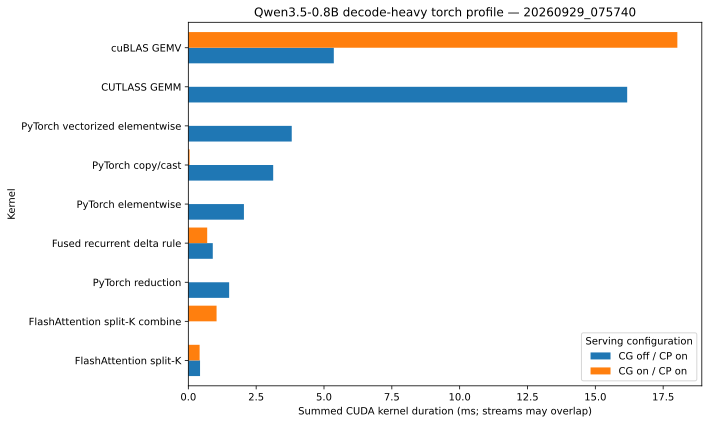

,config,kernel_family,total_ms,calls
0,CG off / CP on,CUTLASS GEMM,16.174119,805
1,CG off / CP on,cuBLAS GEMV,5.361655,291
2,CG off / CP on,PyTorch vectorized elementwise,3.811143,3410
3,CG off / CP on,PyTorch copy/cast,3.127602,1460
4,CG off / CP on,PyTorch elementwise,2.049241,1283
5,CG off / CP on,PyTorch reduction,1.504129,700
6,CG off / CP on,Fused recurrent delta rule,0.901158,162
7,CG off / CP on,"void vllm::act_and_mul_kernel<c10::BFloat16, _...",0.432772,240
8,CG on / CP on,cuBLAS GEMV,18.023278,1150
9,CG on / CP on,FlashAttention split-K combine,1.040969,60


Saved SVG: /home/kevin/Workspace/toyai/llm-serving/output/qwen35-0.8b-profile/20260929_075740/profile-kernel-comparison.svg


In [11]:
profile_svg = None
if profile_run:
    inventory = trace_rows(profile_run['run_dir'])
    successful_attempt = {case['case_id']: f"attempt-{case.get('retries', 0)}" for case in profile_run['summary'].get('cases', []) if case.get('status') == 'SUCCESS'}
    selected_traces = {}
    for item in inventory:
        if item['attempt'] == successful_attempt.get(item['case_id']) and item['case_id'] not in selected_traces:
            selected_traces[item['case_id']] = item
    config_by_case = {row['case_id']: row['config'] for row in profile_diagnostic}
    comparison = []
    for case_id, item in selected_traces.items():
        for kernel in kernel_rows(item['path'], limit=20):
            comparison.append({**kernel, 'case_id': case_id, 'config': config_by_case.get(case_id, case_id)})
    comparison_df = pd.DataFrame(comparison)
    if not comparison_df.empty:
        def kernel_family(name):
            rules = [
                ('gemvx::kernel', 'cuBLAS GEMV'),
                ('cutlass::Kernel2', 'CUTLASS GEMM'),
                ('flash_fwd_splitkv_combine', 'FlashAttention split-K combine'),
                ('flash_fwd_splitkv_kernel', 'FlashAttention split-K'),
                ('fused_recurrent_gated_delta', 'Fused recurrent delta rule'),
                ('causal_conv1d_update', 'Causal Conv1D update'),
                ('unrolled_elementwise_kernel', 'PyTorch copy/cast'),
                ('vectorized_elementwise_kernel', 'PyTorch vectorized elementwise'),
                ('elementwise_kernel', 'PyTorch elementwise'),
                ('reduce_kernel', 'PyTorch reduction'),
                ('triton_per_fused', 'Triton fused elementwise'),
            ]
            return next((label for token, label in rules if token in name), name[:56])
        comparison_df['kernel_family'] = comparison_df['kernel'].map(kernel_family)
        family_df = comparison_df.groupby(['config', 'kernel_family'], as_index=False).agg(total_ms=('total_ms', 'sum'), calls=('calls', 'sum'))
        top_families = family_df.groupby('kernel_family')['total_ms'].sum().nlargest(9).index
        pivot = family_df[family_df['kernel_family'].isin(top_families)].pivot_table(index='kernel_family', columns='config', values='total_ms', aggfunc='sum', fill_value=0)
        pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]
        ax = pivot.plot.barh(figsize=(10, 6), width=0.8)
        ax.set_xlabel('Summed CUDA kernel duration (ms; streams may overlap)')
        ax.set_ylabel('Kernel')
        ax.set_title(f"Qwen3.5-0.8B decode-heavy torch profile — {profile_run['run_id']}")
        ax.legend(title='Serving configuration')
        plt.tight_layout()
        profile_svg = Path(profile_run['run_dir']) / 'profile-kernel-comparison.svg'
        ax.figure.savefig(profile_svg, format='svg', bbox_inches='tight')
        plt.close(ax.figure)
        display(SVG(filename=str(profile_svg)))
        display(family_df.sort_values(['config', 'total_ms'], ascending=[True, False]).groupby('config').head(8).reset_index(drop=True))
        print(f'Saved SVG: {profile_svg}')
    else:
        print('Trace files were present, but no CUDA kernel events were found in the selected successful attempts.')

## Quality evidence (separate from performance)

Quality rows follow the same selected run as the performance panels (the latest compatible completed run by default, or `LLM_SERVING_RUN_IDS` when supplied). They are grouped only when their recorded task settings and named metric match. That check cannot establish compatibility for metadata the current artifacts do not record, such as evaluator version or prompt-template revision. GSM8K and SuperGLUE each use a 10-example smoke subset here; they are not leaderboard estimates. The profile uses the model's full 256K advertised context window.

> **No compatible measured quality results.**

""


Groups sharing recorded task settings and metric: 0


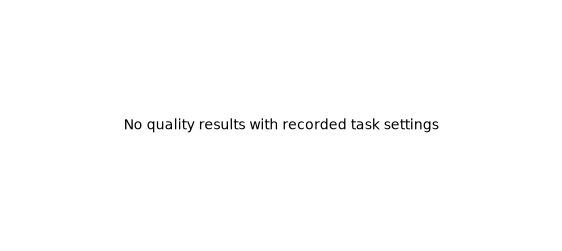

In [12]:
measured_quality = quality_rows(analysis_runs)
if measured_quality:
    quality = measured_quality
    display(Markdown('**Data source: measured quality artifacts.**'))
else:
    quality = []
    display(Markdown('> **No compatible measured quality results.**'))
quality_df = pd.DataFrame(quality)
display(quality_df)
groups = comparable_quality_groups(quality)
print(f'Groups sharing recorded task settings and metric: {len(groups)}')
plot_quality(quality);

## Observations and next decision

After a real run, record what happened in that run's `experiment-notes.json` sidecar and rerun the analysis cells. Check completion and warning columns before comparing values. Treat missing E2E or quality values as unavailable. With one repetition, use the result to choose a focused repeat rather than claim stable variability.

Suggested decision: if the measured decode-heavy delta agrees with the hypothesis, repeat both cases at least three times on the same host/runtime. If a case failed, inspect its saved server log and keep the partial run in history.